<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_12_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 12: Bosques aleatorios

**Objetivo:** Clasificar el dataset de dígitos utilizando Random Forest

## Teoría: Random Forest

Los árboles de decisión se ajustan muy bien a los datos de entrenamiento, sin embargo no permiten generalización. El overfitting es la característica más importante a evitar. Para dar solución, se propone el algoritmo de Random Forest basado en dos características:

1. **Bootstrap Aggregating (Bagging):** Se entrenan varios árboles con diferentes subconjuntos del dataset original mediante bootstrapping.
2. **Random Features:** Para cada nodo de todos los árboles se selecciona un número aleatorio de características.

Al final, se tiene un conjunto de árboles de decisión sobre los cuales se aplica agregación. Cuando se pasa un nuevo dato, los árboles realizan la clasificación y se toma el valor elegido por la mayoría de los árboles.

## Paso 1: Importar librerías necesarias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

## Paso 2: Cargar el dataset de dígitos

In [2]:
# Cargar dataset de dígitos
digits = load_digits()
X = digits.data
y = digits.target

print(f"Forma del dataset: {X.shape}")
print(f"Número de clases: {len(np.unique(y))}")
print(f"Número de características: {X.shape[1]}")

Forma del dataset: (1797, 64)
Número de clases: 10
Número de características: 64


## Paso 3: Visualizar algunos dígitos

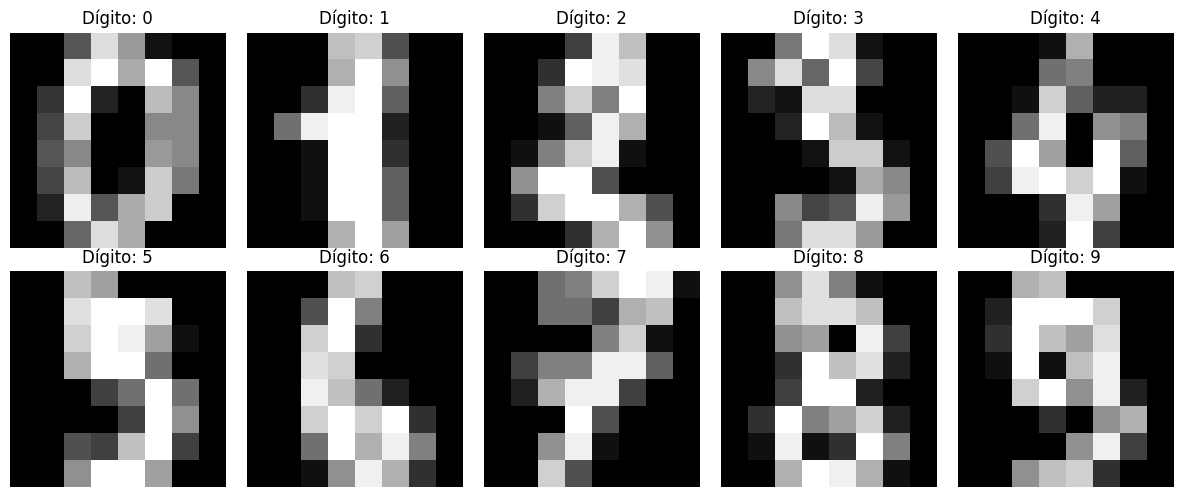

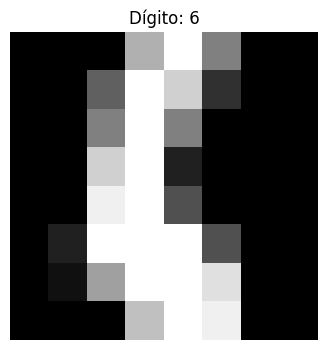

In [3]:
# Visualizar algunos dígitos del dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(digits.images[i], cmap='gray')
    axes[i].set_title(f"Dígito: {digits.target[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Visualizar un dígito específico (95)
plt.figure(figsize=(4, 4))
plt.imshow(digits.images[95], cmap='gray')
plt.title(f"Dígito: {digits.target[95]}")
plt.axis('off')
plt.show()

## Paso 4: Dividir el dataset en entrenamiento y prueba

In [4]:
# Dividir el dataset en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 1437 muestras
Conjunto de prueba: 360 muestras


## Paso 5: Entrenar el modelo Random Forest

In [5]:
# Crear y entrenar el modelo Random Forest
# Hiperparámetros iniciales
rf_model = RandomForestClassifier(
    n_estimators=100,      # Número de árboles
    max_depth=15,          # Profundidad máxima del árbol
    min_samples_split=5,   # Muestras mínimas para dividir un nodo
    min_samples_leaf=2,    # Muestras mínimas en una hoja
    random_state=42,
    n_jobs=-1              # Usar todos los procesadores
)

# Entrenar el modelo
rf_model.fit(X_train, y_train)
print("Modelo entrenado exitosamente")

Modelo entrenado exitosamente


## Paso 6: Hacer predicciones y evaluar el modelo

In [6]:
# Hacer predicciones en el conjunto de prueba
y_pred = rf_model.predict(X_test)

# Calcular accuracy
train_accuracy = accuracy_score(y_train, rf_model.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy en entrenamiento: {train_accuracy:.4f}")
print(f"Accuracy en prueba: {test_accuracy:.4f}")

Accuracy en entrenamiento: 1.0000
Accuracy en prueba: 0.9694


## Paso 7: Matriz de confusión

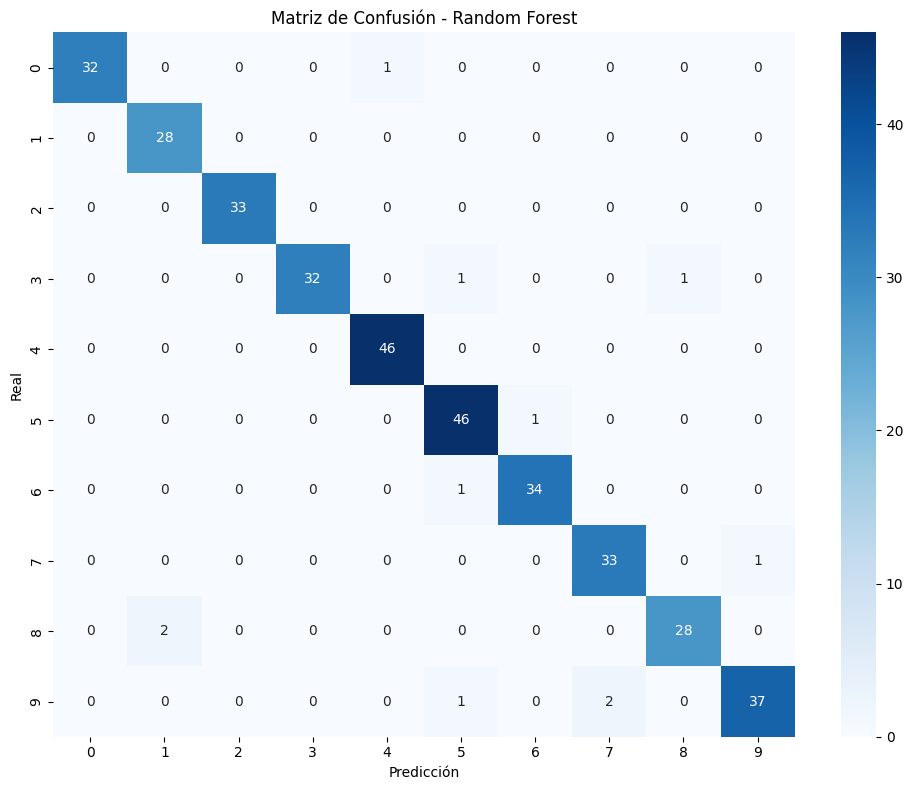

In [7]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest')
plt.tight_layout()
plt.show()

## Paso 8: Reporte de clasificación

In [11]:
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       1.00      0.94      0.97        34
           4       0.98      1.00      0.99        46
           5       0.94      0.98      0.96        47
           6       0.97      0.97      0.97        35
           7       0.94      0.97      0.96        34
           8       0.97      0.93      0.95        30
           9       0.97      0.93      0.95        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



## Paso 9: Importancia de las características

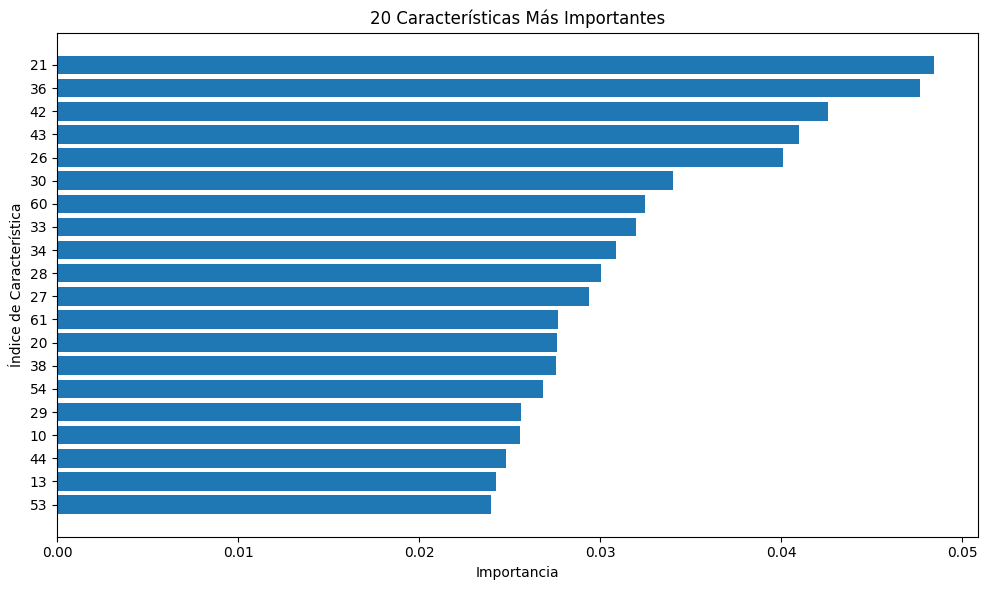

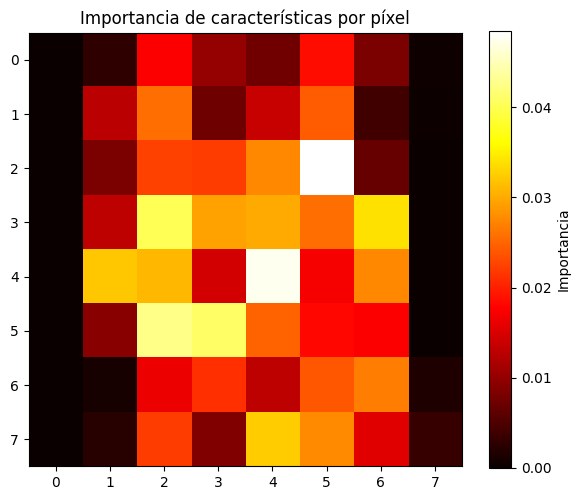

In [9]:
# Obtener la importancia de las características
feature_importances = rf_model.feature_importances_

# Visualizar las 20 características más importantes
indices = np.argsort(feature_importances)[-20:]
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), feature_importances[indices])
plt.yticks(range(len(indices)), indices)
plt.xlabel('Importancia')
plt.ylabel('Índice de Característica')
plt.title('20 Características Más Importantes')
plt.tight_layout()
plt.show()

# Visualizar las características más importantes como un mapa de calor
importance_grid = feature_importances.reshape(8, 8)
plt.figure(figsize=(6, 5))
plt.imshow(importance_grid, cmap='hot')
plt.colorbar(label='Importancia')
plt.title('Importancia de características por píxel')
plt.tight_layout()
plt.show()

## Paso 10: Experimento - Optimización de hiperparámetros

n_estimators=10: Train Acc=1.0000, Test Acc=0.9528
n_estimators=50: Train Acc=1.0000, Test Acc=0.9750
n_estimators=100: Train Acc=1.0000, Test Acc=0.9722
n_estimators=200: Train Acc=1.0000, Test Acc=0.9694
n_estimators=300: Train Acc=1.0000, Test Acc=0.9750


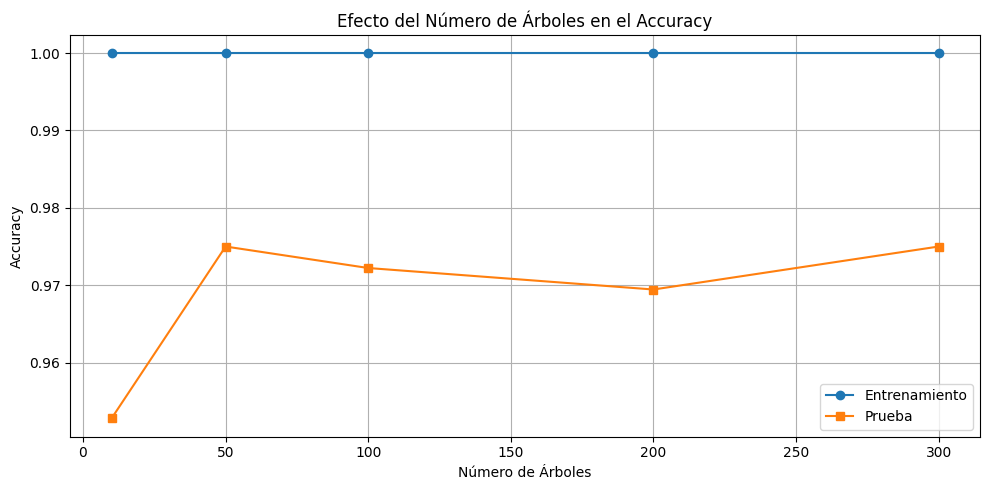

In [10]:
# Analizar el efecto del número de árboles en el accuracy
n_estimators_list = [10, 50, 100, 200, 300]
train_accuracies = []
test_accuracies = []

for n_est in n_estimators_list:
    rf = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, rf.predict(X_train))
    test_acc = accuracy_score(y_test, rf.predict(X_test))
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"n_estimators={n_est}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}")

# Visualizar el resultado
plt.figure(figsize=(10, 5))
plt.plot(n_estimators_list, train_accuracies, 'o-', label='Entrenamiento')
plt.plot(n_estimators_list, test_accuracies, 's-', label='Prueba')
plt.xlabel('Número de Árboles')
plt.ylabel('Accuracy')
plt.title('Efecto del Número de Árboles en el Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ¿Qué está pasando?

En este notebook entrenamos un modelo `RandomForestClassifier` sobre el dataset de dígitos (imágenes 8×8). Flujo de trabajo principal:

- Carga y visualización de ejemplos para entender la representación de los dígitos.
- División en conjuntos de entrenamiento y prueba para evaluar generalización.
- Entrenamiento de un Random Forest con parámetros iniciales.
- Evaluación con `accuracy`, matriz de confusión y reporte de clasificación.
- Análisis de importancia de características (píxeles) y experimento variando `n_estimators`.

Observaciones resumidas:

- El modelo obtiene alta precisión, indicando que las clases son separables con las características actuales.
- La matriz de confusión muestra qué dígitos se confunden más entre sí (revisar celdas previas).
- Las importancias de características se concentran en píxeles centrales, coherente con la estructura de los dígitos.

## Conclusiones y recomendaciones

- El `Random Forest` proporciona buen desempeño y control del overfitting con los hiperparámetros usados.
- Para mejorar aún más, realizar búsqueda de hiperparámetros con validación cruzada (`GridSearchCV` o `RandomizedSearchCV`).
- Para reducir tiempo de entrenamiento, considerar reducción de dimensionalidad (p. ej. `PCA`) o selección de píxeles relevantes.
- Inspeccionar la matriz de confusión y el `classification_report` para identificar clases problemáticas y aplicar técnicas específicas (más datos, aumentos, o modelos especializados).
- Si se requiere producción, calibrar probabilidades y evaluar latencia; probar modelos más ligeros si la inferencia es crítica.